<a href="https://colab.research.google.com/github/ruthAlt/Occupancy-Detection-ML/blob/main/notebooks/MLproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import itertools

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import (train_test_split, learning_curve, validation_curve, KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SequentialFeatureSelector as SFS

from scipy.stats import loguniform, beta, uniform

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as IMBPipeline

import missingno as msno

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/ML_Project/datatraining.txt')

In [4]:
df.head(5)

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


Our dataset has seven columns: date, temperature, humidity, light, CO2, humidity ratio and occupancy.



*   Temperature in Celsius
*   Relative humidity as percentage
*   Light measured in lux
*   CO2 measured in parts per million
*   Humidity ratio derived from temperature and relative humidity measured in kilograms of water vapor per kilogram of air
*   Occupancy (our target) is either 1 for occupied or 0 for not occupied.







In [5]:
df['date'] = pd.to_datetime(df['date'])
df.reset_index(drop=True, inplace=True)

In [6]:
df.describe()

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,8143,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000
mean,2015-02-07 13:41:59.688812544,20.619084,25.731507,119.519375,606.546243,0.003863,0.212330
min,2015-02-04 17:51:00,19.000000,16.745000,0.000000,412.750000,0.002674,0.000000
25%,2015-02-06 03:46:30,19.700000,20.200000,0.000000,439.000000,0.003078,0.000000
50%,2015-02-07 13:41:59,20.390000,26.222500,0.000000,453.500000,0.003801,0.000000
75%,2015-02-08 23:37:30,21.390000,30.533333,256.375000,638.833333,0.004352,0.000000
max,2015-02-10 09:33:00,23.180000,39.117500,1546.333333,2028.500000,0.006476,1.000000
std,NaN,1.016916,5.531211,194.755805,314.320877,0.000852,0.408982


In [7]:
target = 'Occupancy'
X = df.drop(columns=[target])
y = df[target]

In [8]:
X.head(10)

,date,Temperature,Humidity,Light,CO2,HumidityRatio
0,2015-02-04 17:51:00,23.180,27.2720,426.0,721.250000,0.004793
1,2015-02-04 17:51:59,23.150,27.2675,429.5,714.000000,0.004783
2,2015-02-04 17:53:00,23.150,27.2450,426.0,713.500000,0.004779
3,2015-02-04 17:54:00,23.150,27.2000,426.0,708.250000,0.004772
4,2015-02-04 17:55:00,23.100,27.2000,426.0,704.500000,0.004757
5,2015-02-04 17:55:59,23.100,27.2000,419.0,701.000000,0.004757
6,2015-02-04 17:57:00,23.100,27.2000,419.0,701.666667,0.004757
7,2015-02-04 17:57:59,23.100,27.2000,419.0,699.000000,0.004757
8,2015-02-04 17:58:59,23.100,27.2000,419.0,689.333333,0.004757
9,2015-02-04 18:00:00,23.075,27.1750,419.0,688.000000,0.004745


In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8143 entries, 0 to 8142
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           8143 non-null   datetime64[ns]
 1   Temperature    8143 non-null   float64       
 2   Humidity       8143 non-null   float64       
 3   Light          8143 non-null   float64       
 4   CO2            8143 non-null   float64       
 5   HumidityRatio  8143 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 381.8 KB


In [10]:
def add_missing(col, amount):
  X = col.copy()
  size = amount if amount >= 1 else int(len(X)* amount)
  indexes = np.random.choice(len(X), size, replace=False)
  X.iloc[indexes] = np.nan
  return X

def add_missing_rows(df, amount):
  X = df.copy()
  rows, cols = X.shape
  size = amount if amount >= 1 else int(rows * amount)
  indexes = np.random.choice(rows, size, replace = False) + 0.5
  for i in indexes:
    X.loc[i] = np.full((cols,), np.nan)
  X = X.sort_index().reset_index(drop=True)
  return X

In [11]:
X['Light'] = add_missing(X['Light'], 0.10)
X['CO2'] = add_missing(X['CO2'], 0.05)
X['Temperature'] = add_missing(X['Temperature'], 100)

X = add_missing_rows(X, 0.01)

In [12]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8224 entries, 0 to 8223
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           8143 non-null   datetime64[ns]
 1   Temperature    8043 non-null   float64       
 2   Humidity       8143 non-null   float64       
 3   Light          7329 non-null   float64       
 4   CO2            7736 non-null   float64       
 5   HumidityRatio  8143 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 385.6 KB


In [13]:
X.isnull().sum(axis=0) / X.shape[0]


,0
date,0.009849
Temperature,0.022009
Humidity,0.009849
Light,0.108828
CO2,0.059339
HumidityRatio,0.009849


<Axes: >

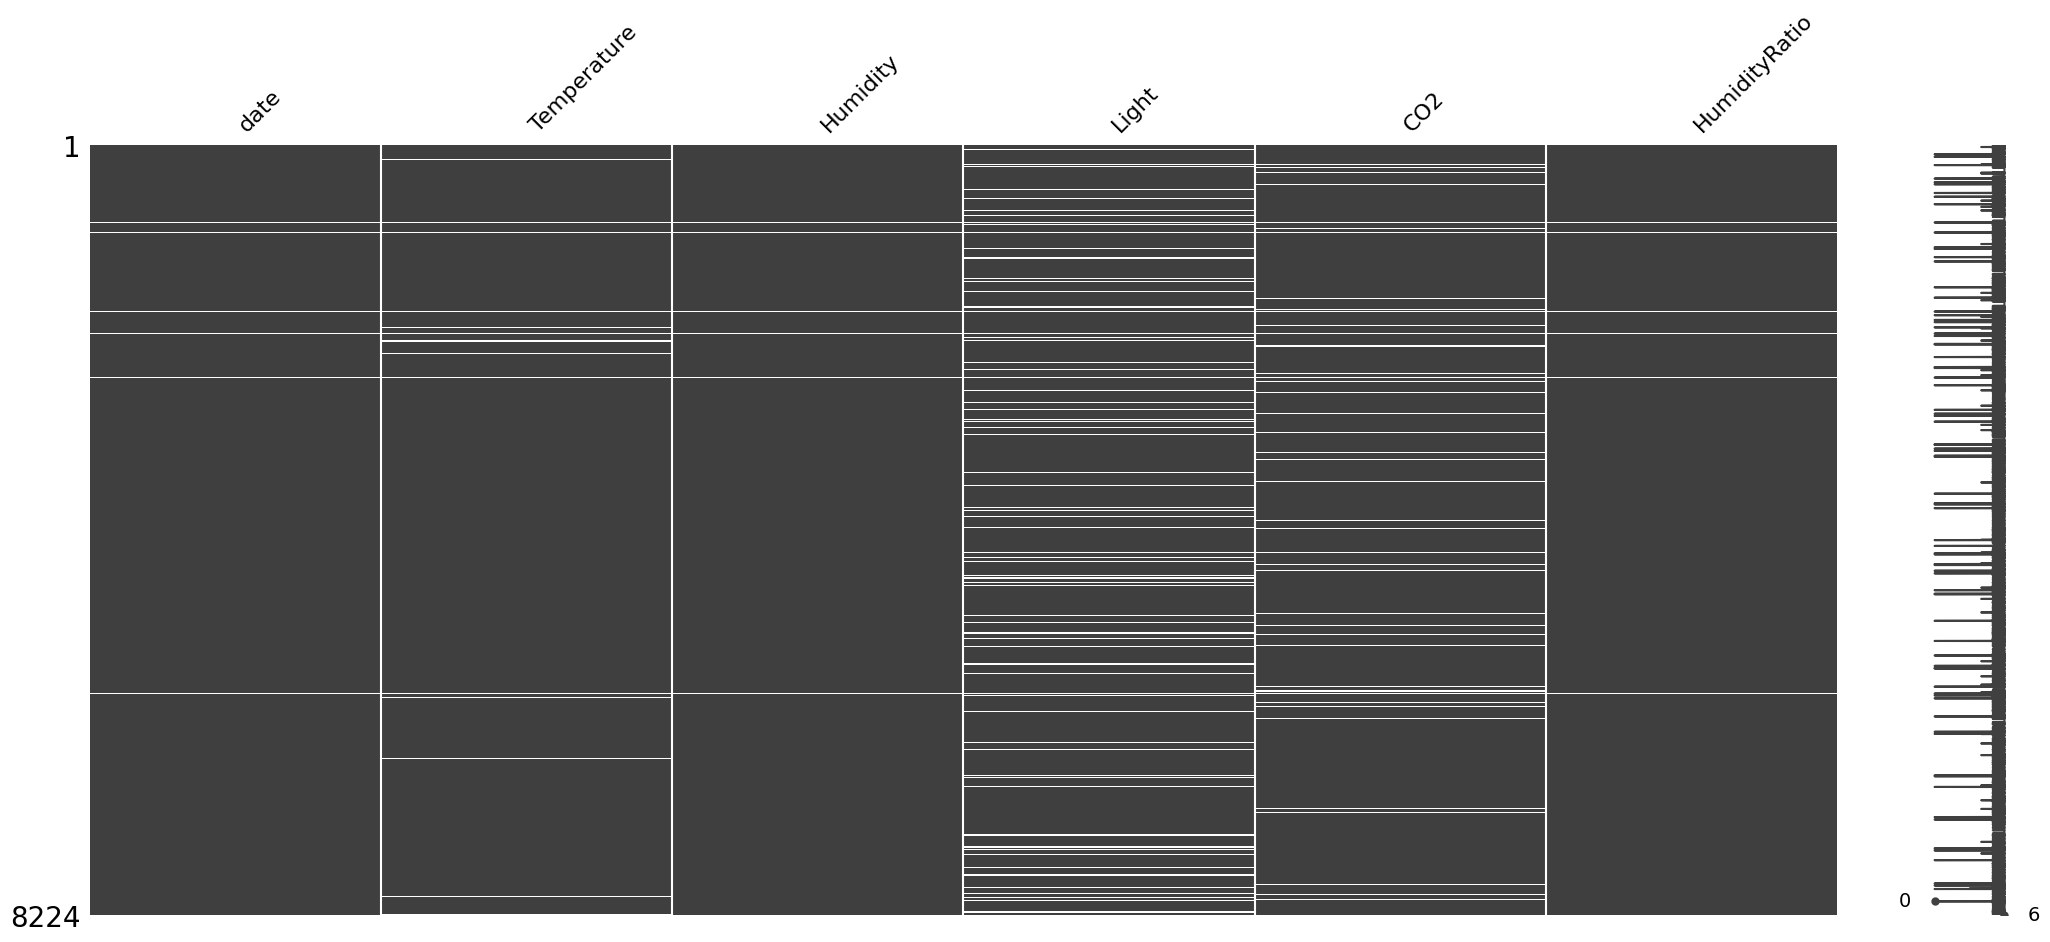

In [14]:
msno.matrix(X)

Since the missing vals are very little we will use imputation method to fill the gaps

# Data Transformation Pipeline

Let's see if there is any relation between occupancy and the hour of the day.

In [15]:
hours_1 = []
hours_0 = []
for date in df[df['Occupancy'] == 1]['date']:
    hours_1.append(date.hour)
for date in df[df['Occupancy'] == 0]['date']:
    hours_0.append(date.hour)

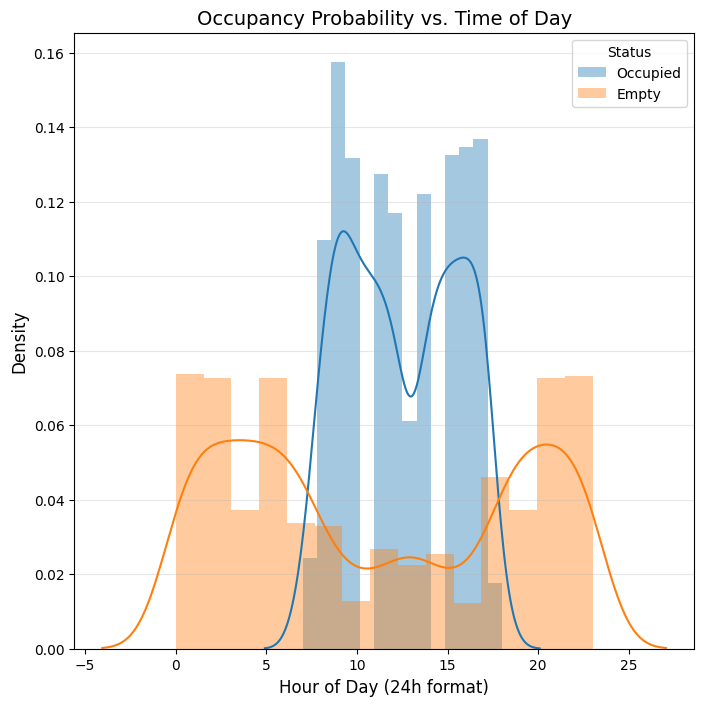

In [22]:
plt.figure(figsize=(8,8))
ax = sns.distplot(hours_1, label='Occupied')
ax = sns.distplot(hours_0, label='Empty')
plt.title('Occupancy Probability vs. Time of Day', fontsize=14)
plt.xlabel('Hour of Day (24h format)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Status')
plt.grid(axis='y', alpha=0.3)

plt.show()

From the above graph, we can see that between 07:00 and 18:00 there are occupants in the environment. But during non-working hours, then we can absolutely say that there are is no occupant. With this information, we can create a new feature from date column as day period.

In [31]:
class WorkingHourTransformer(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self
  def transform(self, X):
    X_df = pd.DataFrame(X)
    date_series = pd.to_datetime(X_df.iloc[:, 0])

    working_hours = date_series.dt.hour.apply(lambda x: 1 if (x >= 7 and x<= 17) else 0)
    return working_hours.values.reshape(-1, 1)


In [32]:
sensor_features = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']

pipeline1 = Pipeline([
    ('imp', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

final_transformation = ColumnTransformer(transformers=[
   ('num_sensors', pipeline1, sensor_features),
   ('working_hour', WorkingHourTransformer(), ['date'])
],
remainder='drop',
verbose_feature_names_out=False
)

Training and test sets